# Test Intent Router Node

This notebook tests the intent_router node with various customer queries to verify routing logic.

In [1]:
# Import the installed package (no path hacks needed with Poetry!)
from sahiloan_chatbot.application.chat_service.workflow.nodes import Nodes
from sahiloan_chatbot.application.chat_service.workflow.state import ChatState
from langchain_core.messages import HumanMessage
import time

# Note: Make sure you've run 'poetry install' first
# This installs sahiloan_chatbot in development mode

/Users/vishnum/Library/Caches/pypoetry/virtualenvs/sahiloan-chatbot-h6twZ8gO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-26 19:29:11.462 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:64 - Looking for eval dataset at: /Users/vishnum/sahiloan-customer-chatbot/data/evals/intent_router.json
2026-01-26 19:29:11.464 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:77 - Loading 25 eval queries for intent caching...
2026-01-26 19:29:22.947 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_load_intent_eval_dataset:89 - ✅ Cached 25 intent router embeddings


In [2]:
# Initialize the Nodes class
nodes = Nodes()

## Helper Function to Test Routing

In [ ]:
def test_intent_routing(query: str) -> dict:
    """Test the intent router with a given query."""
    # Create initial state
    state = ChatState(
        messages=[{"role": "user", "content": query}]
    )
    
    # Run intent router
    start = time.time()
    result_state = nodes.intent_router(state)
    duration = (time.time() - start) * 1000
    
    return {
        "query": query,
        "route": result_state.get("route_to", "Not set"),
        "latency_ms": f"{duration:.2f}"
    }

## Test Cases: Loan Agent Queries

In [ ]:
loan_queries = [
    "I want to apply for a home loan",
    "What is the interest rate for personal loans?",
    "How do I calculate my EMI?",
    "What's my outstanding loan balance?",
    "Can I prepay my loan?",
    "Am I eligible for a business loan?",
    "What are the repayment options?"
]

print("\n=== Testing Loan Agent Queries ===")
for query in loan_queries:
    result = test_intent_routing(query)
    status = "✅" if result["route"] == "loan_agent" else "❌"
    print(f"{status} Route: {result['route']:15} | Latency: {result['latency_ms']:8}ms | Query: {query}")

## Test Cases: Document Agent Queries

## Intent Router Graph with Opik Tracing

✅ Intent router graph compiled successfully
✅ Opik tracer initialized


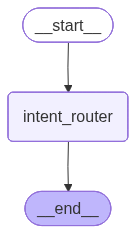

In [3]:
from sahiloan_chatbot.application.chat_service.workflow.graph import create_intent_router_graph
from sahiloan_chatbot.application.chat_service.workflow.state import ChatState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from opik.integrations.langchain import OpikTracer
import uuid
import time

# Initialize memory checkpointer
checkpointer = MemorySaver()

# Create and compile the intent router graph
graph_builder = create_intent_router_graph()
intent_router_graph = graph_builder.compile(checkpointer)

# Initialize Opik tracer
opik_tracer = OpikTracer(
    graph=intent_router_graph.get_graph(xray=True), 
    project_name="sahiloan_chatbot"
)

print("✅ Intent router graph compiled successfully")
print(f"✅ Opik tracer initialized")

# Display the graph
intent_router_graph

## Helper Function for Graph-based Testing

In [5]:
from sahiloan_chatbot import logger

def get_intent_router_response(user_query, thread_id=None):
    response = None
    logger.info(f"Agent Started | Query: {user_query}")
    start = time.perf_counter()

    agent_state = ChatState(messages=[HumanMessage(content=user_query)])
    
    if thread_id is None:
        thread_id = str(uuid.uuid4())[:8]
        logger.info(f"created new thread: {thread_id}")
        
    logger.info(f"Agent State: {agent_state}")
    config = {"configurable": {"thread_id": str(thread_id)}, "callbacks": [opik_tracer]}
    response = intent_router_graph.invoke(agent_state, config=config)
    latency = (time.perf_counter() - start) * 1000
    logger.info(f"Agent Completed | Latency: {latency:.2f}ms")
    logger.info(f"Completed State: \n{response}")
    
    # Return the route_to value (it's a string, not a message list)
    return response.get("route_to")

## Evaluate Intent Router Against Eval Dataset

In [6]:
import json
from pathlib import Path

# Load the eval dataset
eval_dataset_path = Path("../../data/evals/intent_router.json")
with open(eval_dataset_path, 'r') as f:
    eval_dataset = json.load(f)

print(f"✅ Loaded {len(eval_dataset)} eval samples")
print(f"\nSample eval entry:")
print(json.dumps(eval_dataset[0], indent=2))

✅ Loaded 25 eval samples

Sample eval entry:
{
  "input": "What is a home loan and how does it work in India?",
  "reference": "general_agent"
}


### Test All Eval Dataset Queries

In [7]:
def evaluate_intent_router():
    """
    Test all queries from eval dataset and compare predictions with expected routes.
    """
    print("="*80)
    print("EVALUATING INTENT ROUTER")
    print("="*80)
    
    results = {
        "aligned": [],      # Predictions matching expected route
        "not_aligned": [],  # Predictions NOT matching expected route
        "errors": []        # Queries that caused errors
    }
    
    for i, eval_item in enumerate(eval_dataset, 1):
        query = eval_item["input"]
        expected_route = eval_item["reference"]
        
        print(f"\n[{i}/{len(eval_dataset)}] Testing: {query}")
        print(f"   Expected: {expected_route}")
        
        try:
            # Get prediction from intent router
            predicted_route = get_intent_router_response(query)
            print(f"   Predicted: {predicted_route}")
            
            # Compare prediction with expected
            if predicted_route == expected_route:
                print(f"   ✅ ALIGNED")
                results["aligned"].append({
                    "query": query,
                    "expected": expected_route,
                    "predicted": predicted_route
                })
            else:
                print(f"   ❌ NOT ALIGNED")
                results["not_aligned"].append({
                    "query": query,
                    "expected": expected_route,
                    "predicted": predicted_route
                })
        except Exception as e:
            print(f"   ⚠️ ERROR: {str(e)}")
            results["errors"].append({
                "query": query,
                "expected": expected_route,
                "error": str(e)
            })
    
    # Summary
    print("\n" + "="*80)
    print("EVALUATION SUMMARY")
    print("="*80)
    
    total = len(eval_dataset)
    aligned_count = len(results["aligned"])
    not_aligned_count = len(results["not_aligned"])
    error_count = len(results["errors"])
    
    accuracy = (aligned_count / total) * 100 if total > 0 else 0
    
    print(f"\nTotal queries tested: {total}")
    print(f"✅ Aligned (Correct): {aligned_count} ({accuracy:.1f}%)")
    print(f"❌ Not Aligned (Incorrect): {not_aligned_count} ({(not_aligned_count/total)*100:.1f}%)")
    print(f"⚠️ Errors: {error_count}")
    
    # Show not aligned cases
    if results["not_aligned"]:
        print(f"\n{'='*80}")
        print("NOT ALIGNED CASES (Mismatches)")
        print(f"{'='*80}")
        for i, item in enumerate(results["not_aligned"], 1):
            print(f"\n{i}. Query: {item['query']}")
            print(f"   Expected: {item['expected']}")
            print(f"   Predicted: {item['predicted']}")
    
    # Show errors
    if results["errors"]:
        print(f"\n{'='*80}")
        print("ERROR CASES")
        print(f"{'='*80}")
        for i, item in enumerate(results["errors"], 1):
            print(f"\n{i}. Query: {item['query']}")
            print(f"   Expected: {item['expected']}")
            print(f"   Error: {item['error']}")
    
    print("\n" + "="*80)
    
    return results

# Run evaluation
eval_results = evaluate_intent_router()

2026-01-26 19:29:54.786 | INFO     | __main__:get_intent_router_response:5 - Agent Started | Query: What is a home loan and how does it work in India?
2026-01-26 19:29:54.787 | INFO     | __main__:get_intent_router_response:12 - created new thread: 5631627f
2026-01-26 19:29:54.788 | INFO     | __main__:get_intent_router_response:14 - Agent State: {'messages': [HumanMessage(content='What is a home loan and how does it work in India?', additional_kwargs={}, response_metadata={})]}
OPIK: Started logging traces to the "sahiloan_chatbot" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019bfa9a-9ab7-72ec-97cc-116c003bb85c&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.
2026-01-26 19:29:54.815 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:152 - intent_router_started
2026-01-26 19:29:54.816 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:156 - intent_router_user_input: What is a home l

EVALUATING INTENT ROUTER

[1/25] Testing: What is a home loan and how does it work in India?
   Expected: general_agent


2026-01-26 19:29:55.299 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:136 - Semantic match found | similarity: 1.0000 | matched: 'What is a home loan and how does it work in India?' | route: general_agent
2026-01-26 19:29:55.304 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:165 - intent_router_completed | route: general_agent | method: semantic_cache | latency: 488.51ms
2026-01-26 19:29:55.317 | INFO     | __main__:get_intent_router_response:18 - Agent Completed | Latency: 529.83ms
2026-01-26 19:29:55.317 | INFO     | __main__:get_intent_router_response:19 - Completed State: 
{'messages': [HumanMessage(content='What is a home loan and how does it work in India?', additional_kwargs={}, response_metadata={}, id='60e27e8e-baa5-4b60-aee1-886832752216')], 'route_to': 'general_agent'}
2026-01-26 19:29:55.318 | INFO     | __main__:get_intent_router_response:5 - Agent Started | Query: Difference between home loa

   Predicted: general_agent
   ✅ ALIGNED

[2/25] Testing: Difference between home loan and loan against property?
   Expected: general_agent


2026-01-26 19:29:55.737 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:136 - Semantic match found | similarity: 1.0000 | matched: 'Difference between home loan and loan against property?' | route: general_agent
2026-01-26 19:29:55.739 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:165 - intent_router_completed | route: general_agent | method: semantic_cache | latency: 416.45ms
2026-01-26 19:29:55.741 | INFO     | __main__:get_intent_router_response:18 - Agent Completed | Latency: 423.47ms
2026-01-26 19:29:55.742 | INFO     | __main__:get_intent_router_response:19 - Completed State: 
{'messages': [HumanMessage(content='Difference between home loan and loan against property?', additional_kwargs={}, response_metadata={}, id='7d724380-75d7-4185-bdce-9c76d9166626')], 'route_to': 'general_agent'}
2026-01-26 19:29:55.742 | INFO     | __main__:get_intent_router_response:5 - Agent Started | Query: Is sahiloan is tr

...

   Predicted: end
   ✅ ALIGNED

[24/25] Testing: Great, I will come back later.
   Expected: end


2026-01-26 19:30:05.505 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:136 - Semantic match found | similarity: 1.0000 | matched: 'Great, I will come back later.' | route: end
2026-01-26 19:30:05.506 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:165 - intent_router_completed | route: end | method: semantic_cache | latency: 504.48ms
2026-01-26 19:30:05.509 | INFO     | __main__:get_intent_router_response:18 - Agent Completed | Latency: 509.11ms
2026-01-26 19:30:05.509 | INFO     | __main__:get_intent_router_response:19 - Completed State: 
{'messages': [HumanMessage(content='Great, I will come back later.', additional_kwargs={}, response_metadata={}, id='d1d52910-6379-4300-ad85-f205962c5a5a')], 'route_to': 'end'}
2026-01-26 19:30:05.510 | INFO     | __main__:get_intent_router_response:5 - Agent Started | Query: Bye
2026-01-26 19:30:05.510 | INFO     | __main__:get_intent_router_response:12 - created new thr

   Predicted: end
   ✅ ALIGNED

[25/25] Testing: Bye
   Expected: end


2026-01-26 19:30:06.044 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:136 - Semantic match found | similarity: 1.0000 | matched: 'Bye' | route: end
2026-01-26 19:30:06.044 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:165 - intent_router_completed | route: end | method: semantic_cache | latency: 529.88ms
2026-01-26 19:30:06.045 | INFO     | __main__:get_intent_router_response:18 - Agent Completed | Latency: 535.11ms
2026-01-26 19:30:06.046 | INFO     | __main__:get_intent_router_response:19 - Completed State: 
{'messages': [HumanMessage(content='Bye', additional_kwargs={}, response_metadata={}, id='b8966d7b-f8b9-440b-85f1-b1bedd8de1ff')], 'route_to': 'end'}


   Predicted: end
   ✅ ALIGNED

EVALUATION SUMMARY

Total queries tested: 25
✅ Aligned (Correct): 25 (100.0%)
❌ Not Aligned (Incorrect): 0 (0.0%)
⚠️ Errors: 0



### Test Out-of-Scope Query (e.g., "who is shubham")

In [8]:
# Test with a completely unrelated query
print("="*80)
print("TESTING OUT-OF-SCOPE QUERY")
print("="*80)

test_query = "who is shubham"
print(f"\nQuery: {test_query}")
print("Expected: Should route to 'general_agent' or 'end' (not loan/document specific)\n")

result = get_intent_router_response(test_query)
print(f"\n✅ Predicted route: {result}")
print("="*80)

2026-01-26 19:31:12.878 | INFO     | __main__:get_intent_router_response:5 - Agent Started | Query: who is shubham
2026-01-26 19:31:12.880 | INFO     | __main__:get_intent_router_response:12 - created new thread: 2bc979f2
2026-01-26 19:31:12.881 | INFO     | __main__:get_intent_router_response:14 - Agent State: {'messages': [HumanMessage(content='who is shubham', additional_kwargs={}, response_metadata={})]}
2026-01-26 19:31:12.886 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:152 - intent_router_started
2026-01-26 19:31:12.886 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:156 - intent_router_user_input: who is shubham


TESTING OUT-OF-SCOPE QUERY

Query: who is shubham
Expected: Should route to 'general_agent' or 'end' (not loan/document specific)



2026-01-26 19:31:13.462 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:_find_similar_intent:142 - No semantic match | best similarity: 0.2840 (< 0.9)
2026-01-26 19:31:13.467 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:172 - No semantic match, using LLM for intent classification
2026-01-26 19:31:18.026 | DEBUG    | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:186 - intent_router_llm_response: general_agent
2026-01-26 19:31:18.028 | INFO     | sahiloan_chatbot.application.chat_service.workflow.nodes:intent_router:197 - intent_router_completed | route: general_agent | method: llm | latency: 5142.02ms | llm: gpt-4o-mini
2026-01-26 19:31:18.033 | INFO     | __main__:get_intent_router_response:18 - Agent Completed | Latency: 5153.31ms
2026-01-26 19:31:18.034 | INFO     | __main__:get_intent_router_response:19 - Completed State: 
{'messages': [HumanMessage(content='who is shubham', additional_kwargs={}, r


✅ Predicted route: general_agent


### Visualize Results

In [9]:
# Create a simple visualization of results
aligned_count = len(eval_results["aligned"])
not_aligned_count = len(eval_results["not_aligned"])
error_count = len(eval_results["errors"])
total = aligned_count + not_aligned_count + error_count

print("="*80)
print("VISUAL RESULTS BREAKDOWN")
print("="*80)

# Create ASCII bar chart
def create_bar(count, total, width=50):
    filled = int((count / total) * width) if total > 0 else 0
    bar = "█" * filled + "░" * (width - filled)
    percentage = (count / total) * 100 if total > 0 else 0
    return f"{bar} {count}/{total} ({percentage:.1f}%)"

print(f"\n✅ Aligned:     {create_bar(aligned_count, total)}")
print(f"❌ Not Aligned: {create_bar(not_aligned_count, total)}")
print(f"⚠️  Errors:      {create_bar(error_count, total)}")

# Breakdown by route
print(f"\n{'='*80}")
print("BREAKDOWN BY EXPECTED ROUTE")
print(f"{'='*80}")

route_stats = {}
for item in eval_dataset:
    route = item["reference"]
    if route not in route_stats:
        route_stats[route] = {"correct": 0, "incorrect": 0, "total": 0}
    route_stats[route]["total"] += 1

for item in eval_results["aligned"]:
    route = item["expected"]
    route_stats[route]["correct"] += 1

for item in eval_results["not_aligned"]:
    route = item["expected"]
    route_stats[route]["incorrect"] += 1

for route, stats in sorted(route_stats.items()):
    accuracy = (stats["correct"] / stats["total"]) * 100 if stats["total"] > 0 else 0
    print(f"\n{route}:")
    print(f"  Correct: {stats['correct']}/{stats['total']} ({accuracy:.1f}%)")
    print(f"  Incorrect: {stats['incorrect']}/{stats['total']}")

print("\n" + "="*80)

VISUAL RESULTS BREAKDOWN

✅ Aligned:     ██████████████████████████████████████████████████ 25/25 (100.0%)
❌ Not Aligned: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0/25 (0.0%)
⚠️  Errors:      ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0/25 (0.0%)

BREAKDOWN BY EXPECTED ROUTE

document_agent:
  Correct: 5/5 (100.0%)
  Incorrect: 0/5

end:
  Correct: 5/5 (100.0%)
  Incorrect: 0/5

escalation_agent:
  Correct: 5/5 (100.0%)
  Incorrect: 0/5

general_agent:
  Correct: 5/5 (100.0%)
  Incorrect: 0/5

loan_agent:
  Correct: 5/5 (100.0%)
  Incorrect: 0/5



In [ ]:
document_queries = [
    "What documents do I need for a loan application?",
    "How do I upload my KYC documents?",
    "Is my document verification complete?",
    "My document was rejected, what should I do?",
    "Do you accept scanned copies of documents?",
    "I need to submit my income proof",
    "What format should the documents be in?"
]

print("\n=== Testing Document Agent Queries ===")
for query in document_queries:
    result = test_intent_routing(query)
    status = "✅" if result["route"] == "document_agent" else "❌"
    print(f"{status} Route: {result['route']:15} | Latency: {result['latency_ms']:8}ms | Query: {query}")

## Test Cases: General Agent Queries

In [ ]:
general_queries = [
    "Hello, how are you?",
    "What are your office hours?",
    "Where is your nearest branch?",
    "I want to file a complaint",
    "Can I speak to customer support?",
    "How do I reset my password?",
    "Tell me about your company"
]

print("\n=== Testing General Agent Queries ===")
for query in general_queries:
    result = test_intent_routing(query)
    status = "✅" if result["route"] == "general_agent" else "❌"
    print(f"{status} Route: {result['route']:15} | Latency: {result['latency_ms']:8}ms | Query: {query}")

## Test Cases: End Conversation

In [ ]:
end_queries = [
    "Thanks, goodbye!",
    "That's all I needed, bye",
    "I'm done, thank you",
    "Exit"
]

print("\n=== Testing End Queries ===")
for query in end_queries:
    result = test_intent_routing(query)
    status = "✅" if result["route"] == "end" else "❌"
    print(f"{status} Route: {result['route']:15} | Latency: {result['latency_ms']:8}ms | Query: {query}")

## Test Custom Query (Interactive)

In [ ]:
# Test your own custom query
custom_query = "What documents do I need to submit for my loan application?"  # Change this

result = test_intent_routing(custom_query)
print(f"\n📝 Custom Query: {result['query']}")
print(f"🎯 Routed to: {result['route']}")
print(f"⚡ Latency: {result['latency_ms']}ms")